<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjtstefan/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [ ]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_1999/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1999/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


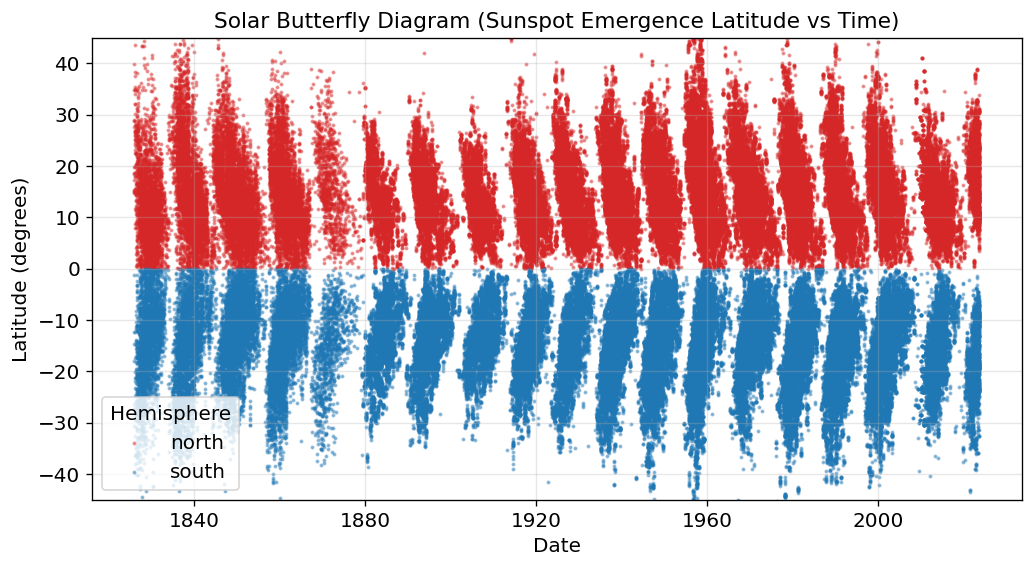

In [ ]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


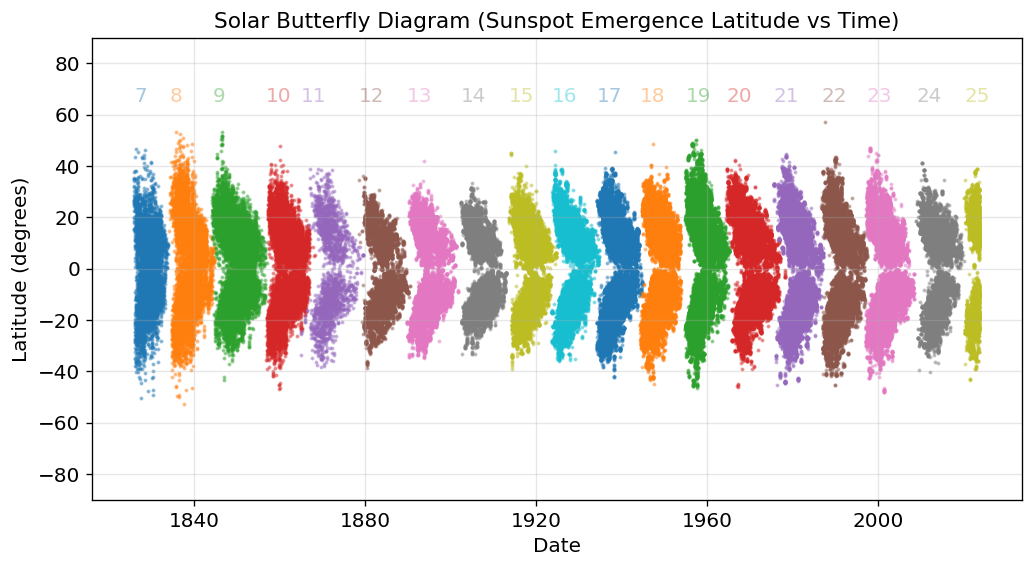

In [ ]:
# Your code here: Visualize a single solar cycle
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for cycle, group in df.groupby("CYCLE"):
    sc = ax.scatter(group["date"], group["latitude"], s=2, label=cycle, alpha=0.4)
    min_date = group['date'].min()
    color = sc.get_facecolors()
    ax.text(min_date,65,str(int(cycle)),color=color)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
#ax.legend(title="Hemisphere")
ax.set_ylim(-90, 90)
plt.show()

Oops, for some reason I thought the task was to color each cycle accordingly!

Choose a cycle: 
 [ 7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24.
 25.] 
8


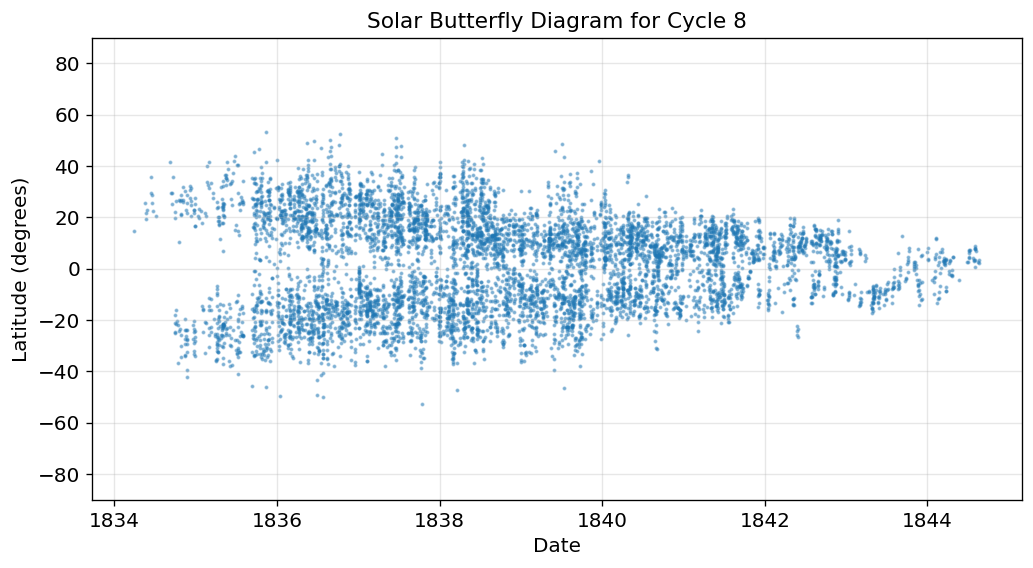

In [ ]:
import matplotlib.pyplot as plt

cycle_opts = df['CYCLE'][df['CYCLE'].notna()].unique()
inp = input(f'Choose a cycle: \n {cycle_opts} \n')

group = df.groupby('CYCLE').get_group(float(inp))

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(group["date"], group["latitude"], s=2, label=cycle, alpha=0.4)

ax.set_title(f"Solar Butterfly Diagram for Cycle {int(inp)}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
#ax.legend(title="Hemisphere")
ax.set_ylim(-90, 90)
plt.show()

Choose a cycle: 
 [ 7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24.
 25.] 
13


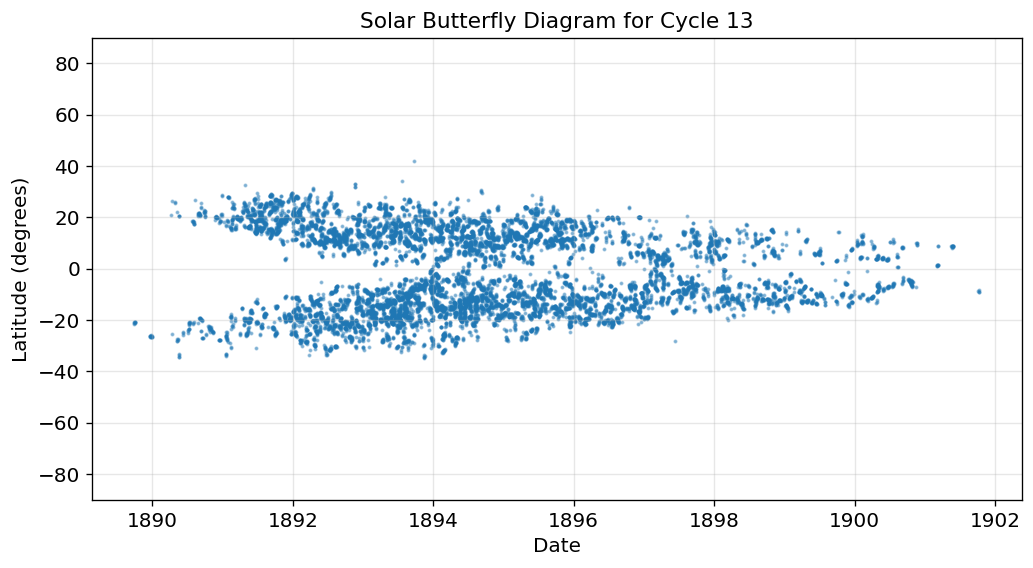

In [ ]:
import matplotlib.pyplot as plt

cycle_opts = df['CYCLE'][df['CYCLE'].notna()].unique()
inp = input(f'Choose a cycle: \n {cycle_opts} \n')

group = df.groupby('CYCLE').get_group(float(inp))

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(group["date"], group["latitude"], s=2, label=cycle, alpha=0.4)

ax.set_title(f"Solar Butterfly Diagram for Cycle {int(inp)}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
#ax.legend(title="Hemisphere")
ax.set_ylim(-90, 90)
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


In [ ]:
# Your code here: Calculate and plot mean latitudinal paths
import numpy as np
group_by = 'Month'

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
df["year"] = df["date"].apply(lambda v: v.year)
df["month"] = df["date"].apply(lambda v: v.month)

mean_lat_no = []
mean_lat_so = []
dates = []
cycle = []
if (group_by == 'Year'):
  for year,group in df.groupby('year'):
    if (group['CYCLE'].mean() == group['CYCLE'].mean()):
      mean_lat_no.append(group[group['hemisphere'] == 'north']['latitude'].mean())
      mean_lat_so.append(group[group['hemisphere'] == 'south']['latitude'].mean())
      dates.append(group['date'].mean())
      cycle.append(int(group['CYCLE'].max()))

if (group_by == 'Month'):
  for year,group in df.groupby('year'):
    if (group['CYCLE'].mean() == group['CYCLE'].mean()):
      for month,o_group in df.groupby('month'):
        mean_lat_no.append(group[group['hemisphere'] == 'north']['latitude'].mean())
        mean_lat_so.append(group[group['hemisphere'] == 'south']['latitude'].mean())
        dates.append(group['date'].mean())
        cycle.append(int(group['CYCLE'].max()))

mean_lat_no = np.asarray(mean_lat_no)
mean_lat_so = np.asarray(mean_lat_so)
dates = np.asarray(dates)
cycle = np.asarray(cycle)

for i in range(cycle.min(),cycle.max()):
  inds, = np.where(cycle == i)
  plt.plot(dates[inds],mean_lat_no[inds],color='blue')
  plt.plot(dates[inds],mean_lat_so[inds],color='red')

inds, = np.where(cycle == cycle.max())
plt.plot(dates[inds],mean_lat_no[inds],color='blue',label='North')
plt.plot(dates[inds],mean_lat_so[inds],color='red',label='South')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Latitude (deg)')
plt.title(f'Mean Latitude by {group_by}')

### Discuss: What does this tell us about the solar cycle's evolution?

The northern and southern sunspots approach the equator at different rates and don't necessarily reach a minimum absolute latitude at the same time. Futhermore, the min/max of the mean monthly latitude isn't the same for all solar cycles. Together, this tells us that the each cycle progresses differently (quasi-periodic, not strictly periodic) and, to some degree, the Northern and Southern hemispheres operate independently.

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


### Response

That's a great question! To effectively prompt an AI assistant to help you learn machine learning and solar physics concepts, consider the following strategies:

1. Be Specific with Your Goal: Clearly state what you want to learn or achieve. Instead of "Tell me about ML," try "Explain the concept of neural networks in machine learning, focusing on how backpropagation works." For solar physics, instead of "Solar flares," try "Describe the physical processes that lead to solar flares and their impact on Earth's magnetosphere."

2. Define Your Current Knowledge Level: Let the AI know your background. Are you a beginner, intermediate, or advanced learner? For example, "Explain neural networks as if I'm new to ML but understand basic calculus," or "Assume I have a solid understanding of fluid dynamics when explaining solar convection."

3. Specify the Desired Output Format: Do you want a summary, a detailed explanation, code examples, analogies, or step-by-step instructions? For instance, "Provide a step-by-step guide to implementing a simple linear regression model in Python using scikit-learn," or "Give me an analogy to understand the concept of 'magnetic reconnection' in solar physics."

4. Break Down Complex Topics: If a topic is vast, break it into smaller, manageable questions. Instead of asking about all of machine learning, start with supervised learning, then move to specific algorithms.

5. Request Examples and Applications: Concrete examples help solidify understanding. "Show me an example of how decision trees are used in medical diagnosis," or "What are some real-world observations that confirm the existence of sunspots?"

6. Ask for Clarification and Elaboration: Don't hesitate to ask follow-up questions. "Can you explain that term in simpler words?" or "How does that concept relate to what we discussed earlier?"

7. Compare and Contrast: This can be very helpful for understanding nuances. "What are the main differences between random forests and gradient boosting?" or "Compare and contrast the solar wind and coronal mass ejections."

8. Request Problem-Solving Assistance (without giving away the answer): If you're stuck on a problem, ask for guidance. "I'm trying to predict stock prices using a time series model. What are some common pitfalls and how can I address them?" or "I'm struggling to understand why sunspots appear dark. Can you elaborate on the temperature differences and magnetic field effects?"

9. Ask for Learning Resources: "What are some good introductory books or online courses for deep learning?" or "Can you recommend any reputable websites or research papers on solar active regions?"

10. Iterate and Refine: Your first prompt might not be perfect. Use the AI's response to formulate better follow-up questions and deepen your understanding.

### Reflection


In future notebooks, I will definitely be using strategies 1 and 3 to guide my AI assistant towards the results that I want. I've found that it needs a bit of guidance in order to give advice related to my original question, so being specific is helpful. Strategies 6 and 10 are also useful; oftentimes, AI will give a solution to a related problem but not specifically what I was asking. Following up with additional questions and clarifications generally returns more useful information to me.